In [142]:
import sys
from pathlib import Path
import math

import pandas as pd
from scipy.stats import beta, gamma
from scipy import special
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd().parent))

from utils.cred_intervals import credible_intervals
from utils.triple_plot import normality_report

In [143]:
# 1. Datos (DataFrame con columna de éxitos/fracasos: 1 o 0)
df = pd.read_csv("../data/datos_inmobiliarios_ready.csv")
df.head()

,price_amount,admin_fee,area_built_m2,bedrooms,bathrooms,parking_spaces,stratum,floor,age_bracket_code,latitude,...,locality_frec,neighborhood_grouped_frec,publisher_type_desarrollador,publisher_type_inmobiliaria,property_type_apartaestudio,property_type_casa,property_type_casa_campestre,property_type_finca,property_type_habitacion,meses_ofertado
0,8.800000e+08,736000.00,160.000,3.0,3.0,2,4.0,2,4.0,4.711642,...,0.275462,0.690441,0,0,0,1,0,0,0,43
1,6.500000e+08,271123.04,153.400,4.0,2.0,1,3.0,2,5.0,4.655459,...,0.060219,0.690441,0,0,0,1,0,0,0,43
2,6.250000e+08,643500.00,120.000,4.0,3.0,2,5.0,1,4.0,4.764007,...,0.310195,0.690441,0,0,0,1,0,0,0,42
3,4.700000e+08,560000.00,56.000,1.0,2.0,1,4.0,2,2.0,4.721554,...,0.310195,0.690441,0,0,0,0,0,0,0,41
4,1.170000e+09,869954.98,79.473,2.0,2.0,2,6.0,14,1.0,4.685839,...,0.310195,0.025536,0,1,0,0,0,0,0,41


# Beta - Binomial



## Para `property_type_casa`, toda Bogota
Según el CNPV-2018 del DANE, el 61,53% de la población vive en casa y el 32,75% en apartamento.

Como el mercado de vivienda usada se abastece del stock existente, se toma esa proporción como media a priori de θ = P(la propiedad sea casa). Se fija entonces una Beta(α, β) con media α/(α+β) ≈ 0,62 y una varianza de $0{,}0112$, luego es una prior Moderadamente informativa con:

$\alpha_0 \approx 12,40$

$\beta_0 \approx 7,60$

https://www.dane.gov.co/files/censo2018/informacion-tecnica/cnpv-2018-comunicado-3ra-entrega.pdf

In [144]:
# 2. Creación de la Prior Beta(a, b)
a_prior, b_prior = 12.40, 7.6
prior = beta(a_prior, b_prior)

# 3. Datos observados desde la columna del DataFrame
muestra = df["property_type_casa"].sample(n=300, random_state=42)

k = muestra.sum()
n = len(muestra)  # O directamente n = 300

# Likelihood normalizada como función de densidad equivalente a Beta(k + 1, n - k + 1)
likelihood = beta(k + 1, n - k + 1)

# 4. Creación de la Posterior Beta(a + k, b + n - k)
a_post = a_prior + k
b_post = b_prior + (n - k)
posterior = beta(a_post, b_post)

# Ejemplo de uso: Media y Moda (Estimador MAP) de la posterior
print(f"Media posterior (Esperanza): {posterior.mean():.3f}")
print(f"Moda posterior (MAP): {(a_post - 1) / (a_post + b_post - 2):.3f}")

Media posterior (Esperanza): 0.379
Moda posterior (MAP): 0.379


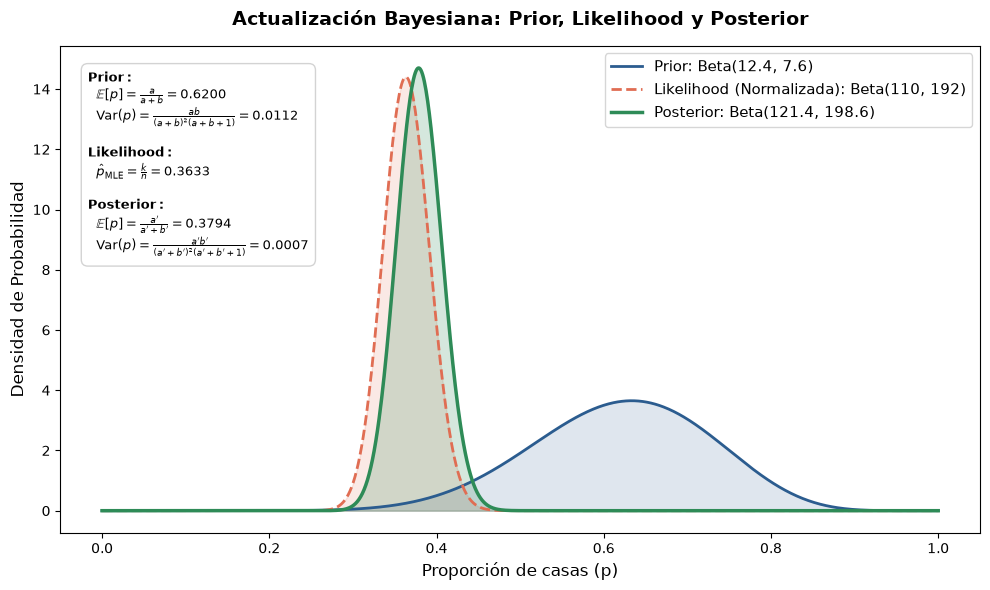

In [145]:
e_prior = a_prior / (a_prior + b_prior)
var_prior = (a_prior * b_prior) / (((a_prior + b_prior)**2) * (a_prior + b_prior + 1))

# Verosimilitud (Estimador de Máxima Verosimilitud - MLE)
mle_lik = k / n

# Posterior
e_post = a_post / (a_post + b_post)
var_post = (a_post * b_post) / (((a_post + b_post)**2) * (a_post + b_post + 1))

mu_post = a_post / (a_post + b_post)
x = np.linspace(0, 1, 1000)

# Configuración de la figura
plt.figure(figsize=(10, 6))

# Trazado de las curvas con Seaborn
sns.lineplot(x=x, y=prior.pdf(x), label=f"Prior: Beta({a_prior}, {b_prior})", color="#2b5c8f", linewidth=2)
sns.lineplot(x=x, y=likelihood.pdf(x), label=f"Likelihood (Normalizada): Beta({k+1}, {n-k+1})", color="#e06d53", linewidth=2, linestyle="--")
sns.lineplot(x=x, y=posterior.pdf(x), label=f"Posterior: Beta({a_post}, {b_post})", color="#2e8b57", linewidth=2.5)

# Sombreado bajo las curvas
plt.fill_between(x, prior.pdf(x), alpha=0.15, color="#2b5c8f")
plt.fill_between(x, likelihood.pdf(x), alpha=0.15, color="#e06d53")
plt.fill_between(x, posterior.pdf(x), alpha=0.2, color="#2e8b57")

# Recuadro con fórmulas y valores estimados (esquina superior izquierda)
stats_text = (
    r"$\mathbf{Prior:}$" "\n"
    rf"  $\mathbb{{E}}[p] = \frac{{a}}{{a+b}} = {e_prior:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(p) = \frac{{ab}}{{(a+b)^2(a+b+1)}} = {var_prior:.4f}$" "\n\n"
    r"$\mathbf{Likelihood:}$" "\n"
    rf"  $\hat{{p}}_{{\mathrm{{MLE}}}} = \frac{{k}}{{n}} = {mle_lik:.4f}$" "\n\n"
    r"$\mathbf{Posterior:}$" "\n"
    rf"  $\mathbb{{E}}[p] = \frac{{a'}}{{a'+b'}} = {e_post:.4f}$" "\n"
    rf"  $\mathrm{{Var}}(p) = \frac{{a'b'}}{{(a'+b')^2(a'+b'+1)}} = {var_post:.4f}$"
)

plt.gca().text(
    0.03, 0.95, stats_text,
    transform=plt.gca().transAxes,
    fontsize=9.5,
    verticalalignment='top',
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", edgecolor="#cccccc", alpha=0.85)
)

# Detalles del gráfico
plt.title("Actualización Bayesiana: Prior, Likelihood y Posterior", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Proporción de casas (p)", fontsize=12)
plt.ylabel("Densidad de Probabilidad", fontsize=12)
plt.legend(fontsize=11, loc="upper right")

plt.tight_layout()
plt.show()

### Intervalos Credibilidad

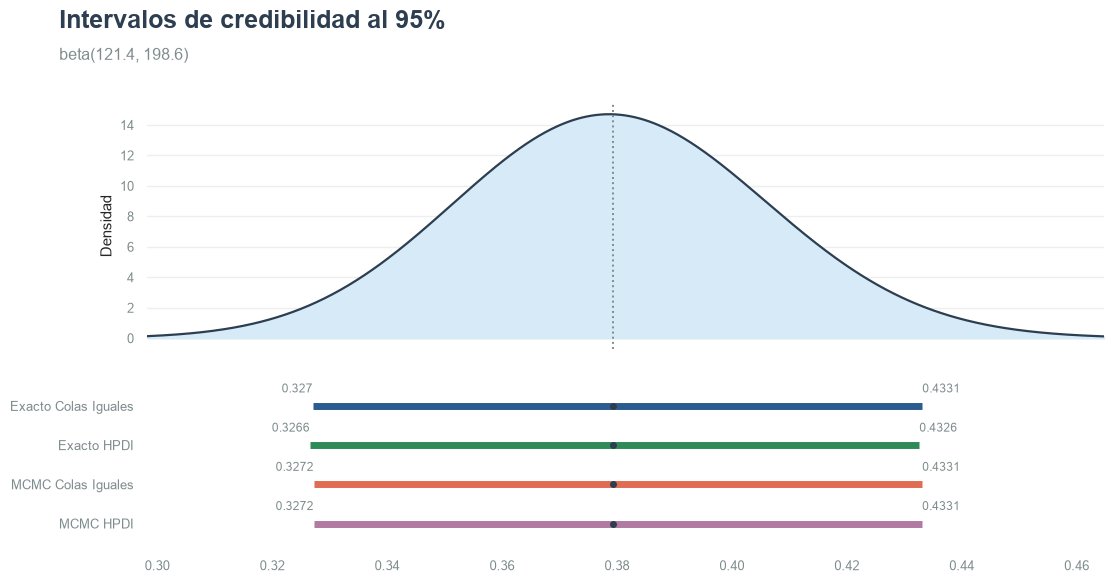

,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.327046,0.433132,0.106086
1,Exacto,HPDI,0.95,0.326552,0.432620,0.106068
2,MCMC,Colas Iguales,0.95,0.327217,0.433122,0.105905
3,MCMC,HPDI,0.95,0.327211,0.433102,0.105891


In [146]:
credible_intervals(posterior, plot=True)

### Predictivas

con m = 150 y x_new = 70

In [147]:
def get_pred_binom(alpha, beta, x_new, m, only_res = False):
    alpha_pred = x_new + alpha
    beta_pred = beta + m - x_new
    normalize_term = math.comb(m, x_new)
    prob = normalize_term * ((special.beta(alpha_pred, beta_pred)) / (special.beta(alpha, beta)))
    expected_value = m * (alpha / (alpha + beta))
    if only_res:
        return prob
    return {
        'prob': float(prob),
        'alpha_pred' : float(alpha_pred),
        'beta_pred' : float(beta_pred),
        'expected_value': float(expected_value),
    }

#### Prior

In [148]:
priores = get_pred_binom(a_prior, b_prior, 70, 150)
priores

{'prob': 0.00930200808535001,
 'alpha_pred': 82.4,
 'beta_pred': 87.6,
 'expected_value': 93.0}

#### Posterior

In [149]:
posteriores = get_pred_binom(a_post, b_post, 70, 150)
posteriores

{'prob': 0.010699020877873685,
 'alpha_pred': 191.4,
 'beta_pred': 278.6,
 'expected_value': 56.90625}

# Multinomial dirichlet



## Para `price_amount` (discretizado), toda Bogota
Los precios se discretizan con los umbrales en salarios mínimos de Guerrero (2025), convertidos a pesos con el SMMLV de 2024 ($1.300.000): Económico agrupa los segmentos VIP y VIS (15–135 SMMLV), Normal los segmentos 3 y 4 (135–775 SMMLV) y Lujo los segmentos 5 a 7 (más de 775 SMMLV). 

El corte de 135 SMMLV coincide con el tope legal de la Vivienda de Interés Social. El prior se calibra con la Tabla 3 de ese estudio, que a partir del Censo de Edificaciones (DANE / Coordenada Urbana) reporta 66.119 unidades de vivienda producidas en el Borde Metropolitano de Bogotá en 2006, 2009 y 2013; las proporciones a priori son la participación de cada grupo en ese total (69,3% / 23,6% / 7,1%), escaladas a α₀ = 100.

**Cortes (SMMLV 2024 = $1.300.000):**

| Categoría | Segmentos | Rango SMMLV | Rango COP |
| :--- | :--- | :--- | :--- |
| **Económico** | S1 + S2 | 15 – 135 | \$19,5M – \$175,5M |
| **Normal** | S3 + S4 | 135 – 775 | \$175,5M – \$1.007,5M |
| **Lujo** | S5 + S6 + S7 | > 775 | > \$1.007,5M |

**Tabla de cálculo ($\alpha_j = \alpha_0 \cdot p_j, \alpha_0 = 100$):**[cite: 3]

| Categoría | Cálculo | Unidades | $p_j$ | $\alpha_j$ |
| :--- | :--- | :--- | :--- | :--- |
| **Económico** | $10.234 + 35.617$ | $45.851$ | $0{,}6935$ | $69{,}35$ |
| **Normal** | $10.781 + 4.805$ | $15.586$ | $0{,}2357$ | $23{,}57$ |
| **Lujo** | $2.707 + 1.626 + 349$ | $4.682$ | $0{,}0708$ | $7{,}08$ |
| **Total** | | **66.119** | **1** | **100** |

<br>

> Guerrero Hurtado, A. (2025). Concentración de capital para la producción de vivienda en el Borde Metropolitano de Bogotá: un enfoque multiescalar del oligopolio inmobiliario. *Bitácora Urbano Territorial*, *35*(3). https://doi.org/10.15446/bitacora.v35n2.122787

>acceso alternativo: https://dialnet.unirioja.es/servlet/articulo?codigo=10491834

In [150]:
df_diric = df.copy()
SMMLV_2024 = 1_300_000

def clasificador_precios(col):
    if pd.isna(col):
        return np.nan
    s = col / SMMLV_2024
    if s < 15:
        return np.nan          # fuera del rango del paper
    if s <= 135:
        return "Economico"
    elif s <= 775:
        return "Normal"
    return "Lujo"

# crear categorias


df_diric["categorias"] = df_diric["price_amount"].apply(clasificador_precios)

muestra = df_diric["categorias"].sample(n=300, random_state=42)

# prior: Tabla 3 de Guerrero (2025), 2006-09 + 2013
uds = np.array([10234 + 35617,          # S1 + S2
                10781 + 4805,           # S3 + S4
                2707 + 1626 + 349])     # S5 + S6 + S7
a0_prior = 100
alpha_prior = a0_prior * uds / uds.sum()

# observado

x = muestra.value_counts().reindex(["Economico", "Normal", "Lujo"], fill_value=0).to_numpy()
n = np.sum(x)
# posterior

alpha_post = alpha_prior + x
a0_post = np.sum(alpha_post)


In [151]:
alpha_prior

array([69.34617886, 23.57264931,  7.08117183])

In [152]:
n

np.int64(300)

In [153]:
x.sum()

np.int64(300)

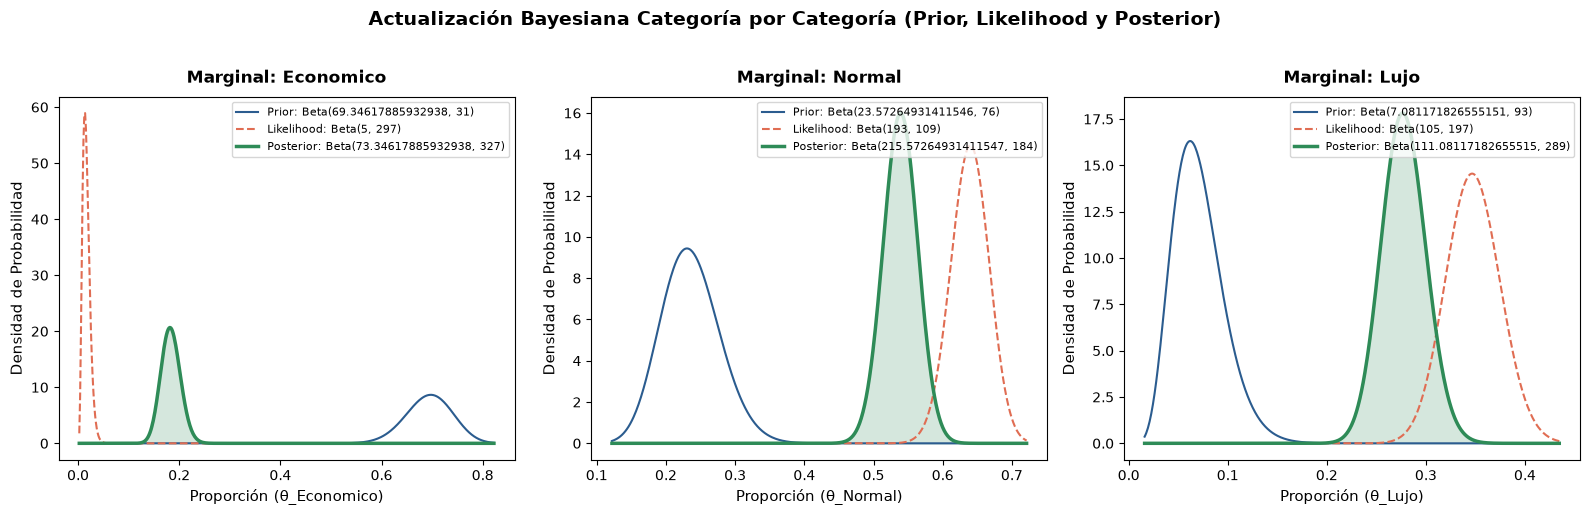

RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA
Fórmulas:
  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)]
  • Likelihood: θ_MLE = k / n
  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)]
--------------------------------------------------------------------------------

Categoría: ECONOMICO
  [Prior]     E[θ] = 0.6935  |  Var(θ) = 0.002105
  [Likelihood] θ_MLE = 0.0133
  [Posterior] E[θ] = 0.1834  |  Var(θ) = 0.000373

Categoría: NORMAL
  [Prior]     E[θ] = 0.2357  |  Var(θ) = 0.001784
  [Likelihood] θ_MLE = 0.6400
  [Posterior] E[θ] = 0.5389  |  Var(θ) = 0.000620

Categoría: LUJO
  [Prior]     E[θ] = 0.0708  |  Var(θ) = 0.000651
  [Likelihood] θ_MLE = 0.3467
  [Posterior] E[θ] = 0.2777  |  Var(θ) = 0.000500


In [154]:
categorias = ["Economico", "Normal", "Lujo"]

# Creación de la figura con 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Estructuras para almacenar los resultados numéricos
res_prior, res_lik, res_post = [], [], []

for i, (cat, ax) in enumerate(zip(categorias, axes)):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pri_dist = beta(a_pri, b_pri)
    lik_dist = beta(a_lik, b_lik)
    pos_dist = beta(a_pos, b_pos)

    # Rango de x
    low = min(pri_dist.ppf(0.001), lik_dist.ppf(0.001), pos_dist.ppf(0.001))
    high = max(pri_dist.ppf(0.999), lik_dist.ppf(0.999), pos_dist.ppf(0.999))
    x_axis = np.linspace(max(0, low), min(1, high), 500)

    # Trazado de las curvas
    sns.lineplot(x=x_axis, y=pri_dist.pdf(x_axis), ax=ax, label=f"Prior: Beta({a_pri}, {b_pri:.0f})", color="#2b5c8f", lw=1.5)
    sns.lineplot(x=x_axis, y=lik_dist.pdf(x_axis), ax=ax, label=f"Likelihood: Beta({a_lik}, {b_lik})", color="#e06d53", linestyle="--", lw=1.5)
    sns.lineplot(x=x_axis, y=pos_dist.pdf(x_axis), ax=ax, label=f"Posterior: Beta({a_pos}, {b_pos:.0f})", color="#2e8b57", lw=2.5)

    # Sombreado bajo la posterior
    ax.fill_between(x_axis, pos_dist.pdf(x_axis), alpha=0.2, color="#2e8b57")

    # Formato del gráfico
    ax.set_title(f"Marginal: {cat}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"Proporción (θ_{cat})", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

    # --- CÁLCULO DE ESTADÍSTICOS ---
    e_pri = a_pri / (a_pri + b_pri)
    var_pri = (a_pri * b_pri) / (((a_pri + b_pri)**2) * (a_pri + b_pri + 1))

    mle_lik = k_i / n

    e_pos = a_pos / (a_pos + b_pos)
    var_pos = (a_pos * b_pos) / (((a_pos + b_pos)**2) * (a_pos + b_pos + 1))

    # Guardar métricas calculadas
    res_prior.append((e_pri, var_pri))
    res_lik.append(mle_lik)
    res_post.append((e_pos, var_pos))

plt.suptitle("Actualización Bayesiana Categoría por Categoría (Prior, Likelihood y Posterior)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- IMPRESIÓN CON FÓRMULAS Y VALORES DEBAJO DEL GRÁFICO ---
print("=" * 80)
print("RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA")
print("=" * 80)
print("Fórmulas:")
print("  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)]")
print("  • Likelihood: θ_MLE = k / n")
print("  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)]")
print("-" * 80)

for i, cat in enumerate(categorias):
    e_pri, var_pri = res_prior[i]
    mle_lik = res_lik[i]
    e_pos, var_pos = res_post[i]

    print(f"\nCategoría: {cat.upper()}")
    print(f"  [Prior]     E[θ] = {e_pri:.4f}  |  Var(θ) = {var_pri:.6f}")
    print(f"  [Likelihood] θ_MLE = {mle_lik:.4f}")
    print(f"  [Posterior] E[θ] = {e_pos:.4f}  |  Var(θ) = {var_pos:.6f}")

print("=" * 80)

### Intervalos

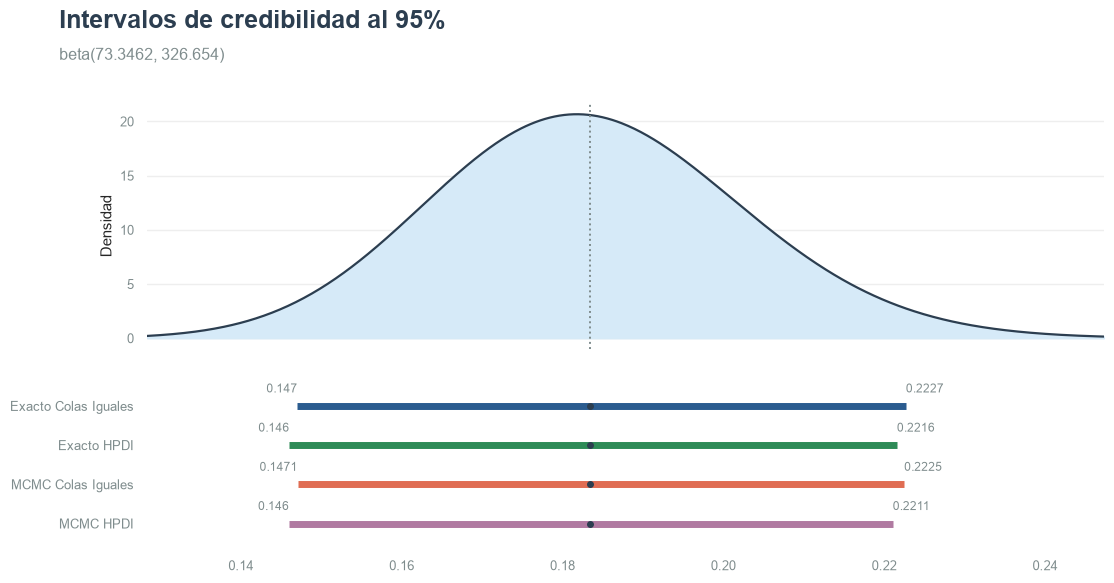

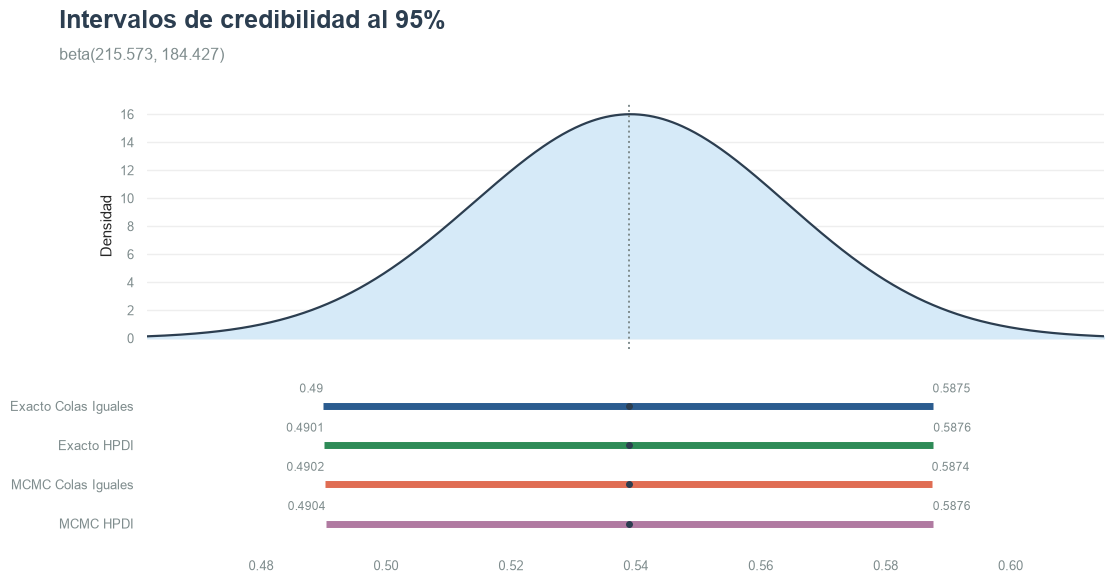

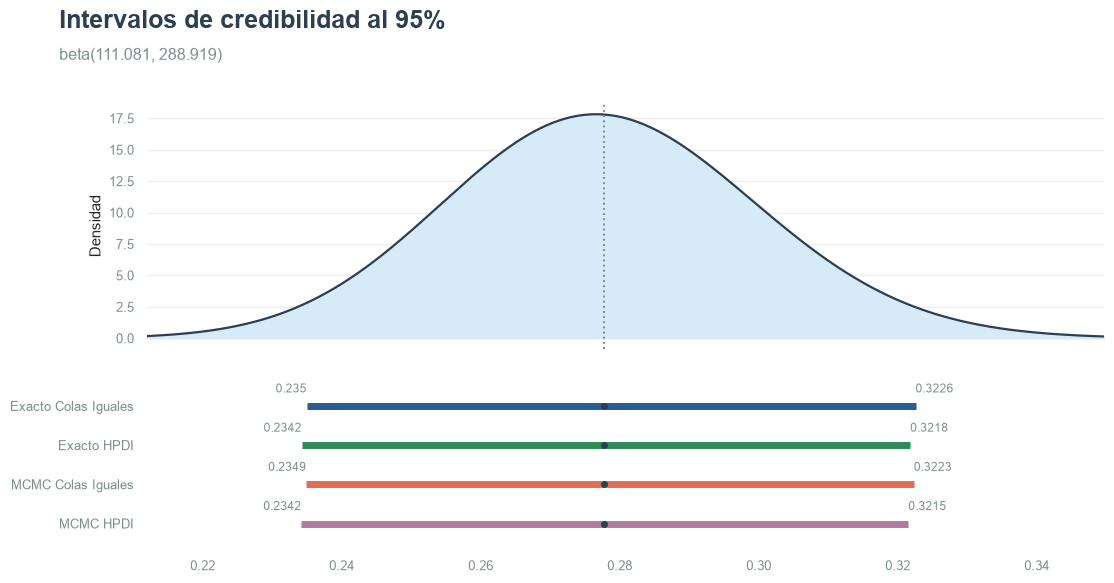

In [155]:
informe_intervalos = {}
for i, (cat) in enumerate(categorias):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pos_dist = beta(a_pos, b_pos)

    informe_intervalos[cat] = credible_intervals(pos_dist, plot=True)

In [156]:
for k, v in informe_intervalos.items():
    print("="*20)
    print(k)
    print("="*20)
    display(v)

Economico


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.147032,0.222697,0.075665
1,Exacto,HPDI,0.95,0.146034,0.221586,0.075551
2,MCMC,Colas Iguales,0.95,0.147054,0.222485,0.075432
3,MCMC,HPDI,0.95,0.145997,0.221069,0.075072


Normal


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.489984,0.587511,0.097527
1,Exacto,HPDI,0.95,0.490114,0.587640,0.097525
2,MCMC,Colas Iguales,0.95,0.490158,0.587383,0.097225
3,MCMC,HPDI,0.95,0.490362,0.587553,0.097191


Lujo


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.234953,0.322558,0.087605
1,Exacto,HPDI,0.95,0.234236,0.321793,0.087557
2,MCMC,Colas Iguales,0.95,0.234893,0.322316,0.087424
3,MCMC,HPDI,0.95,0.234191,0.321529,0.087338


### Predictivas

In [157]:
def get_pred_dirichlet_multinomial(
    alpha, x=None, k=None, n_tilde=1, only_res=False
):
    """Calcula las probabilidades predictivas individuales y el valor esperado

    para un nuevo experimento de n_tilde observaciones bajo el modelo
    Multinomial-Dirichlet.

    Parámetros:
    - alpha: array-like, vector de hiperparámetros a priori alpha_k.
    - k: int (opcional), índice de una categoría específica. Si es None,
    retorna para todas.
    - n_tilde: int, número de nuevos ensayos futuros (por defecto 1).
    """
    alpha = np.array(alpha, dtype=float)

    # Si se pasan conteos observados x, actualizamos a los parámetros posteriores
    if x is not None:
        x = np.array(x, dtype=float)
        alpha_post = alpha + x
    else:
        alpha_post = alpha

    # alpha_0 es la suma de los parametros alpha (posteriores o priores)
    alpha_0_post = np.sum(alpha_post)

    # Probabilidad individual de la próxima observación (n_tilde = 1)
    probs = alpha_post / alpha_0_post

    # Esperanza del número de ocurrencias en n_tilde observaciones
    expected_values = n_tilde * probs

    if k is not None:
        probs = probs[k]
        expected_values = expected_values[k]

    if only_res:
        return probs

    return {
        'prob_individual': probs,
        'expected_value': expected_values,
        'alpha_post': alpha_post,
        'alpha_0_post': alpha_0_post,
    }

#### Prior

In [158]:
res = get_pred_dirichlet_multinomial(alpha_prior, n_tilde=50)

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados.drop(columns=['Conteo_x', 'Alpha_Post'])

,Categoria,Alpha_Prior,Prob_Individual,Valor_Esperado_n50
0,Economico,69.346179,0.693462,34.673089
1,Normal,23.572649,0.235726,11.786325
2,Lujo,7.081172,0.070812,3.540586


#### Posterior

In [159]:
res = get_pred_dirichlet_multinomial(alpha_prior, x=x, n_tilde=50)

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados

,Categoria,Alpha_Prior,Conteo_x,Alpha_Post,Prob_Individual,Valor_Esperado_n50
0,Economico,69.346179,4,73.346179,0.183365,9.168272
1,Normal,23.572649,192,215.572649,0.538932,26.946581
2,Lujo,7.081172,104,111.081172,0.277703,13.885146


## Para `property_type`

El prior se calibra con el estudio de la Unidad Administrativa Especial de Catastro Distrital (UAECD) y Fincaraíz sobre vivienda usada en las siete principales aglomeraciones del país, que sobre 1.351.073 ofertas reporta, para el segmento de venta, una composición de 68% apartamentos, 30% casas y 2% apartaestudios.

Para compensar la falta de casa campestre, habitación y finca se les reparte el 1%  del conteo total que se desea tener, por lo tanto el alpha prior se define como:

$$\begin{pmatrix} \alpha_{\text{apartamento}} \\ \alpha_{\text{casa}} \\ \alpha_{\text{apartaestudio}} \\ \alpha_{\text{casa\_camp}} \\ \alpha_{\text{hab}} \\ \alpha_{\text{finca}} \end{pmatrix} = \begin{pmatrix} 100.98 \\ 44.55 \\ 2.97 \\ 0.5 \\ 0.5 \\ 0.5 \end{pmatrix}$$

de esta manera construyendo una prior informatva, frente a la sub muestra de 300 que se tomará del dataframe.

| Categoría | $p_j$ | $\alpha_j = 150 \cdot p_j$ |
| :--- | :--- | :--- |
| **apartamento** | $0{,}99 \times 0{,}68 = 0{,}6732$ | $100{,}98$ |
| **casa** | $0{,}99 \times 0{,}30 = 0{,}2970$ | $44{,}55$ |
| **apartaestudio** | $0{,}99 \times 0{,}02 = 0{,}0198$ | $2{,}97$ |
| **casa_campestre** | $0{,}01 / 3 \approx 0{,}003333$ | $0{,}50$ |
| **habitacion** | $0{,}01 / 3 \approx 0{,}003333$ | $0{,}50$ |
| **finca** | $0{,}01 / 3 \approx 0{,}003333$ | $0{,}50$ |
| **Total** | **1** | **150** |


https://www.catastrobogota.gov.co/noticia/fincaraiz-presento-la-perspectiva-del-mercado-inmobiliario-en-colombia

In [160]:
dummy_cols = [col for col in df.columns if col.startswith("property_type_")]
# recuperar la columna property_type para usar con multinomial
df["property_type"] = (
    df[dummy_cols]
    .idxmax(axis=1)
    .str.replace("property_type_", "")
    .where(df[dummy_cols].sum(axis=1) == 1, "apartamento")
)

In [161]:
# orden: apartamento, casa, apartaestudio, casa_campestre, habitacion, finca
alpha_prior = np.array([100.98, 44.55, 2.97, 0.50, 0.50, 0.50])   # a0 = 150

a0_prior = np.sum(alpha_prior)

# observado
muestra = df["property_type"].sample(n=300, random_state=42)
x = muestra.value_counts().reindex(
    ["apartamento", "casa", "apartaestudio", "casa_campestre", "habitacion", "finca"],
    fill_value=0
    ).to_numpy()

n = np.sum(x)

# posterior
alpha_post = alpha_prior + x
a0_post = np.sum(alpha_post)

In [162]:
x/x.sum()

array([0.55333333, 0.36333333, 0.08      , 0.00333333, 0.        ,
       0.        ])

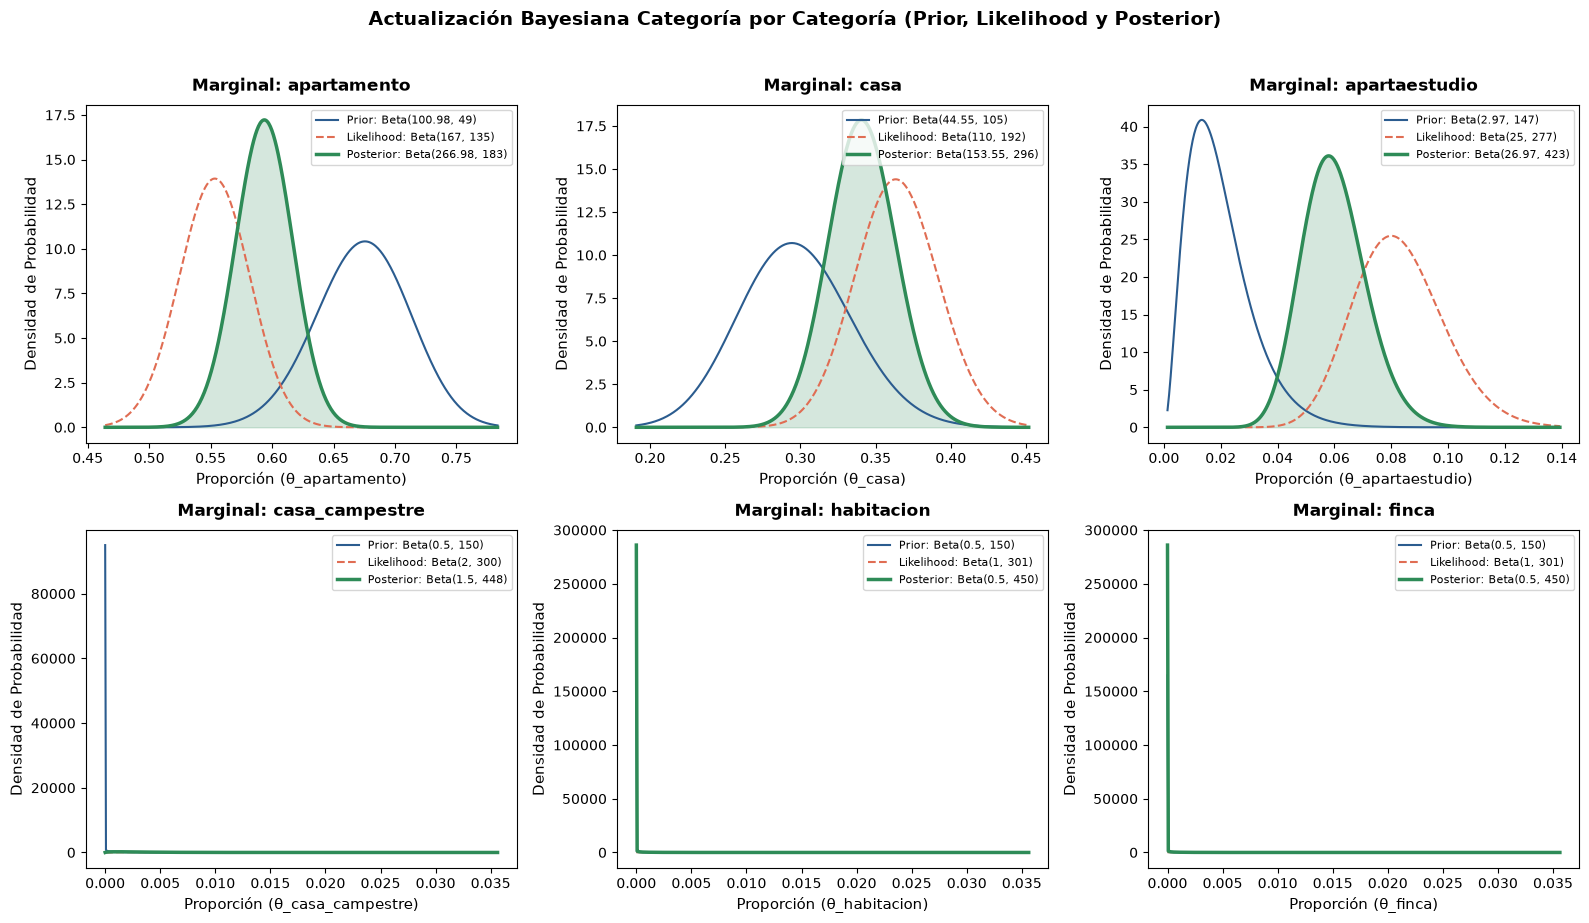

RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA
Fórmulas:
  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)]
  • Likelihood: θ_MLE = k / n
  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)]
--------------------------------------------------------------------------------

Categoría: APARTAMENTO
  [Prior]     E[θ] = 0.6732  |  Var(θ) = 0.001457
  [Likelihood] θ_MLE = 0.5533
  [Posterior] E[θ] = 0.5933  |  Var(θ) = 0.000535

Categoría: CASA
  [Prior]     E[θ] = 0.2970  |  Var(θ) = 0.001383
  [Likelihood] θ_MLE = 0.3633
  [Posterior] E[θ] = 0.3412  |  Var(θ) = 0.000498

Categoría: APARTAESTUDIO
  [Prior]     E[θ] = 0.0198  |  Var(θ) = 0.000129
  [Likelihood] θ_MLE = 0.0800
  [Posterior] E[θ] = 0.0599  |  Var(θ) = 0.000125

Categoría: CASA_CAMPESTRE
  [Prior]     E[θ] = 0.0033  |  Var(θ) = 0.000022
  [Likelihood] θ_MLE = 0.0033
  [Posterior] E[θ] = 0.0033  |  Var(θ) = 0.000007

Categoría: HABITACION
  [P

In [163]:
categorias = ["apartamento", "casa", "apartaestudio", "casa_campestre", "habitacion", "finca"]
# Creación de la figura con 6 subplots en una cuadrícula 2x3

fig, axes = plt.subplots(2, 3, figsize=(16, 9))

# Estructuras para almacenar los resultados numéricos
res_prior, res_lik, res_post = [], [], []

# Usamos axes.flat para iterar sobre los 6 ejes de forma unidimensional
for i, (cat, ax) in enumerate(zip(categorias, axes.flat)):
    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pri_dist = beta(a_pri, b_pri)
    lik_dist = beta(a_lik, b_lik)
    pos_dist = beta(a_pos, b_pos)

    # Rango de x
    low = min(pri_dist.ppf(0.001), lik_dist.ppf(0.001), pos_dist.ppf(0.001))
    high = max(pri_dist.ppf(0.999), lik_dist.ppf(0.999), pos_dist.ppf(0.999))
    x_axis = np.linspace(max(0, low), min(1, high), 500)

    # Trazado de las curvas
    sns.lineplot(x=x_axis, y=pri_dist.pdf(x_axis), ax=ax, label=f"Prior: Beta({a_pri}, {b_pri:.0f})", color="#2b5c8f", lw=1.5)
    sns.lineplot(x=x_axis, y=lik_dist.pdf(x_axis), ax=ax, label=f"Likelihood: Beta({a_lik}, {b_lik})", color="#e06d53", linestyle="--", lw=1.5)
    sns.lineplot(x=x_axis, y=pos_dist.pdf(x_axis), ax=ax, label=f"Posterior: Beta({a_pos}, {b_pos:.0f})", color="#2e8b57", lw=2.5)

    # Sombreado bajo la posterior
    ax.fill_between(x_axis, pos_dist.pdf(x_axis), alpha=0.2, color="#2e8b57")

    # Formato del gráfico
    ax.set_title(f"Marginal: {cat}", fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel(f"Proporción (θ_{cat})", fontsize=11)
    ax.set_ylabel("Densidad de Probabilidad", fontsize=11)
    ax.legend(fontsize=8, loc="upper right")

    # --- CÁLCULO DE ESTADÍSTICOS ---
    e_pri = a_pri / (a_pri + b_pri)
    var_pri = (a_pri * b_pri) / (((a_pri + b_pri)**2) * (a_pri + b_pri + 1))

    mle_lik = k_i / n

    e_pos = a_pos / (a_pos + b_pos)
    var_pos = (a_pos * b_pos) / (((a_pos + b_pos)**2) * (a_pos + b_pos + 1))

    # Guardar métricas calculadas
    res_prior.append((e_pri, var_pri))
    res_lik.append(mle_lik)
    res_post.append((e_pos, var_pos))

plt.suptitle("Actualización Bayesiana Categoría por Categoría (Prior, Likelihood y Posterior)", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

# --- IMPRESIÓN CON FÓRMULAS Y VALORES DEBAJO DEL GRÁFICO ---
print("=" * 80)
print("RESUMEN DE ESTIMACIONES Y FÓRMULAS POR CATEGORÍA")
print("=" * 80)
print("Fórmulas:")
print("  • Prior:      E[θ] = a / (a + b)            | Var(θ) = (a * b) / [(a + b)² * (a + b + 1)]")
print("  • Likelihood: θ_MLE = k / n")
print("  • Posterior:  E[θ] = a' / (a' + b')        | Var(θ) = (a' * b') / [(a' + b')² * (a' + b' + 1)]")
print("-" * 80)

for i, cat in enumerate(categorias):
    e_pri, var_pri = res_prior[i]
    mle_lik = res_lik[i]
    e_pos, var_pos = res_post[i]

    print(f"\nCategoría: {cat.upper()}")
    print(f"  [Prior]     E[θ] = {e_pri:.4f}  |  Var(θ) = {var_pri:.6f}")
    print(f"  [Likelihood] θ_MLE = {mle_lik:.4f}")
    print(f"  [Posterior] E[θ] = {e_pos:.4f}  |  Var(θ) = {var_pos:.6f}")

print("=" * 80)

### Invervalos

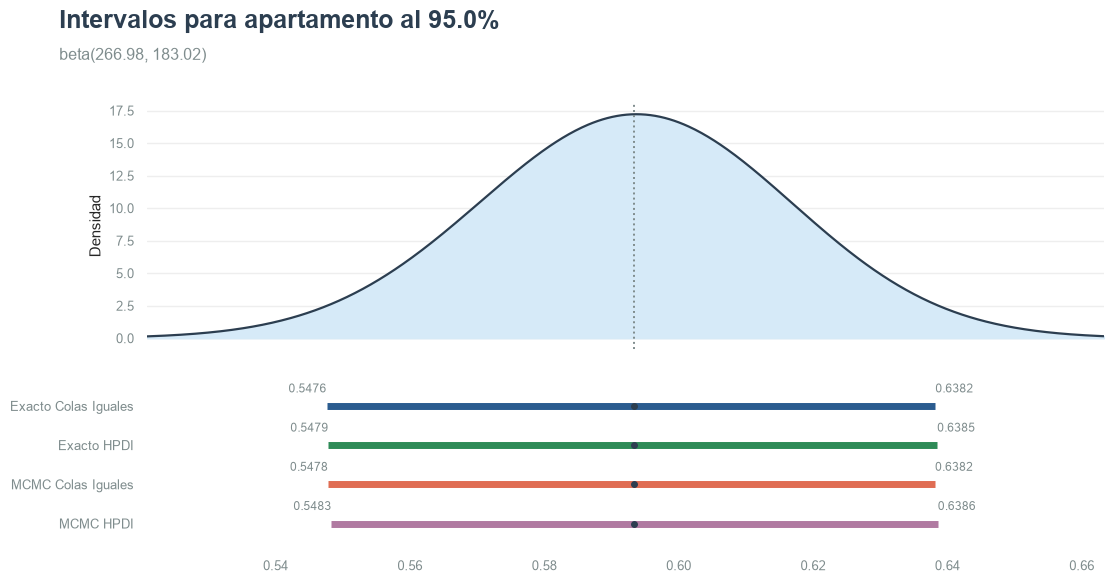

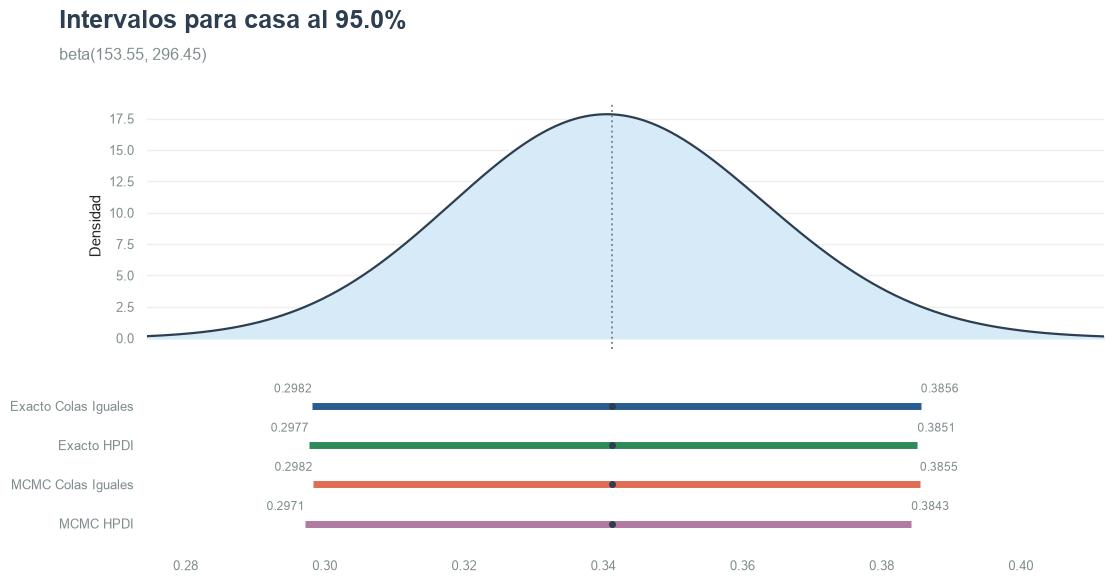

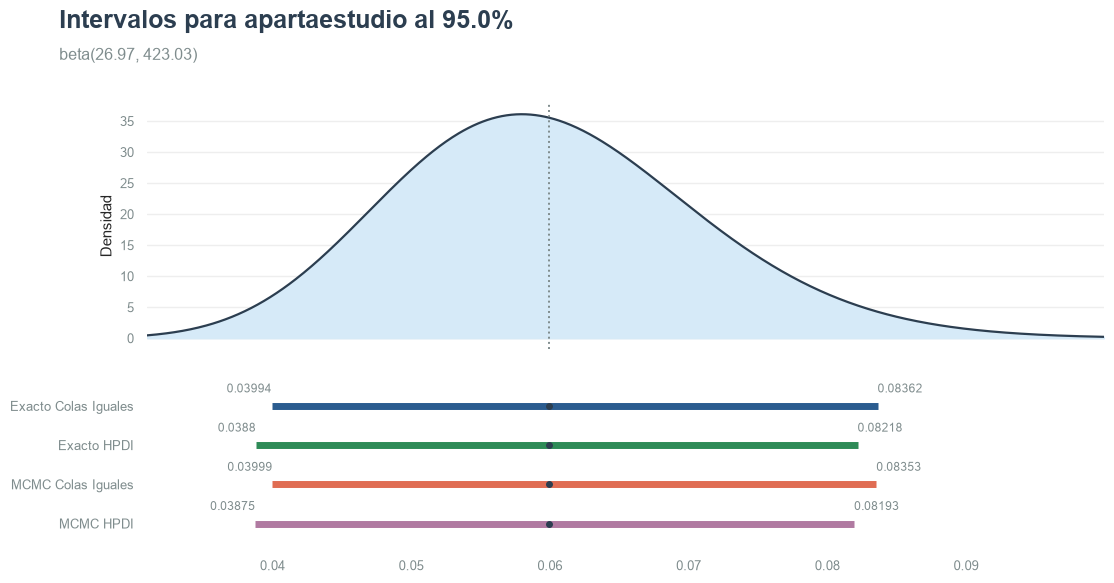

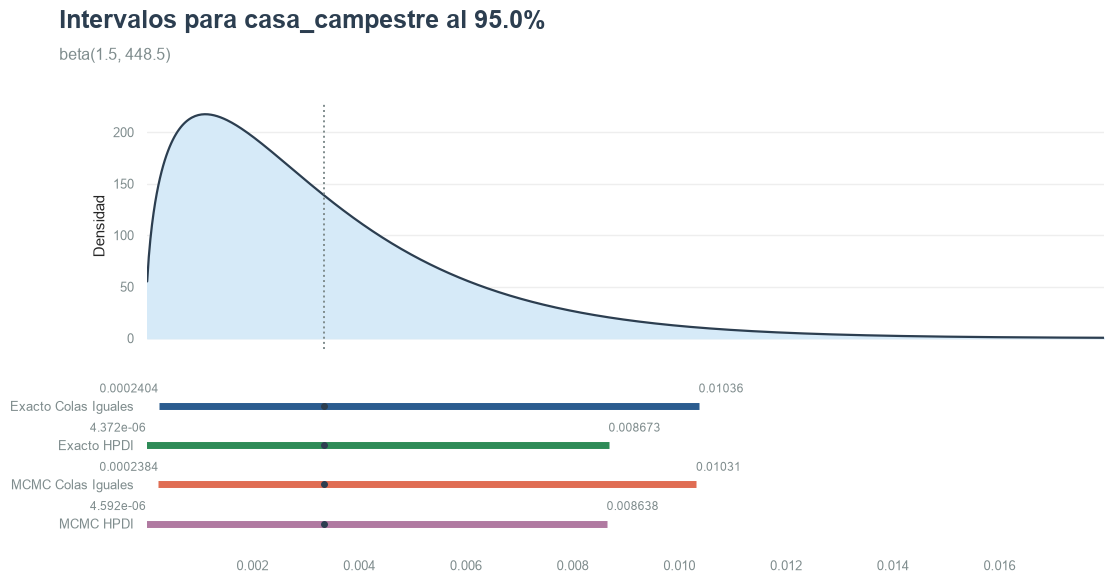

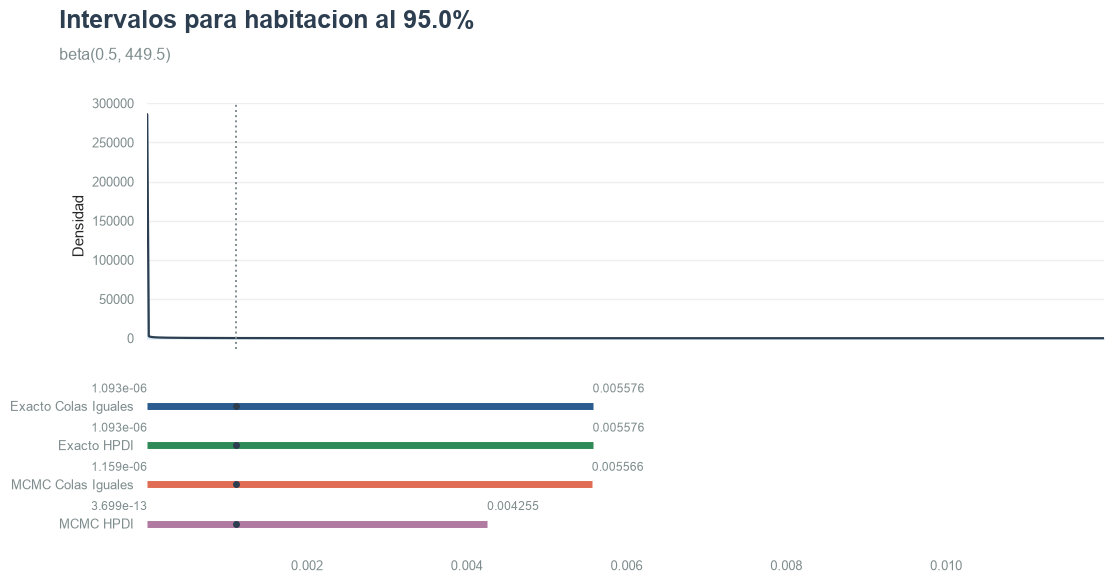

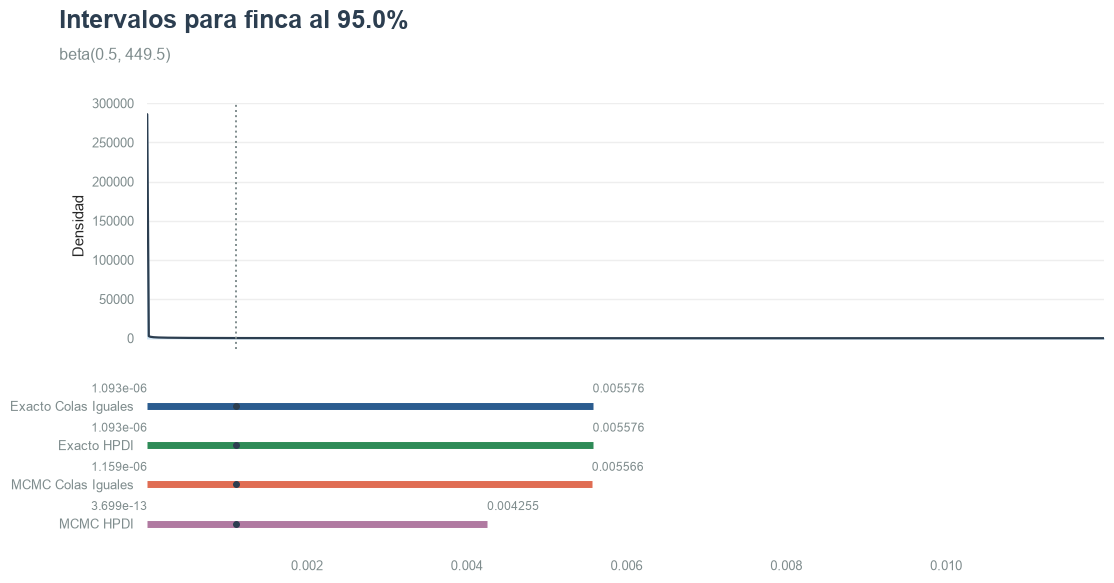

In [164]:
level = 0.95
informe_intervalos = {}
for i, (cat) in enumerate(categorias):
    title = f'Intervalos para {cat} al {level*100}%'

    # Marginal Prior: Beta(alpha_i, a0_prior - alpha_i)
    a_pri = alpha_prior[i]
    b_pri = a0_prior - a_pri

    # Marginal Likelihood equivalente: Beta(k_i + 1, n - k_i + 1)
    k_i = x[i]
    a_lik = k_i + 1
    b_lik = n - k_i + 1

    # Marginal Posterior: Beta(alpha_post_i, a0_post - alpha_post_i)
    a_pos = alpha_post[i]
    b_pos = a0_post - a_pos

    pos_dist = beta(a_pos, b_pos)

    informe_intervalos[cat] = credible_intervals(pos_dist, plot=True, title=title)

In [165]:
for k, v in informe_intervalos.items():
    print("="*20)
    print(k)
    print("="*20)
    display(v)

apartamento


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.547583,0.638209,0.090625
1,Exacto,HPDI,0.95,0.547863,0.638482,0.090619
2,MCMC,Colas Iguales,0.95,0.547806,0.638166,0.090360
3,MCMC,HPDI,0.95,0.548313,0.638580,0.090267


casa


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.298158,0.385623,0.087465
1,Exacto,HPDI,0.95,0.297697,0.385142,0.087446
2,MCMC,Colas Iguales,0.95,0.298242,0.385502,0.087259
3,MCMC,HPDI,0.95,0.297097,0.384260,0.087163


apartaestudio


...

,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,0.000240,0.010362,0.010122
1,Exacto,HPDI,0.95,0.000004,0.008673,0.008668
2,MCMC,Colas Iguales,0.95,0.000238,0.010313,0.010074
3,MCMC,HPDI,0.95,0.000005,0.008638,0.008633


habitacion


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,1.093009e-06,0.005576,0.005575
1,Exacto,HPDI,0.95,1.093009e-06,0.005576,0.005575
2,MCMC,Colas Iguales,0.95,1.159363e-06,0.005566,0.005565
3,MCMC,HPDI,0.95,3.698848e-13,0.004255,0.004255


finca


,fuente,tipo,nivel,limite_inferior,limite_superior,ancho
0,Exacto,Colas Iguales,0.95,1.093009e-06,0.005576,0.005575
1,Exacto,HPDI,0.95,1.093009e-06,0.005576,0.005575
2,MCMC,Colas Iguales,0.95,1.159363e-06,0.005566,0.005565
3,MCMC,HPDI,0.95,3.698848e-13,0.004255,0.004255


### Predictivas

#### Prior

In [166]:
alpha_prior

array([100.98,  44.55,   2.97,   0.5 ,   0.5 ,   0.5 ])

In [167]:
res = get_pred_dirichlet_multinomial(alpha_prior, n_tilde=50)

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados.drop(columns=['Conteo_x', 'Alpha_Post'])

,Categoria,Alpha_Prior,Prob_Individual,Valor_Esperado_n50
0,apartamento,100.98,0.673200,33.660000
1,casa,44.55,0.297000,14.850000
2,apartaestudio,2.97,0.019800,0.990000
3,casa_campestre,0.50,0.003333,0.166667
4,habitacion,0.50,0.003333,0.166667
5,finca,0.50,0.003333,0.166667


#### Posterior

In [168]:
res = get_pred_dirichlet_multinomial(alpha_prior, x=x, n_tilde=50)

# 2. Construir el DataFrame mapeando por categoría
df_resultados = pd.DataFrame(
    {
        'Categoria': categorias,
        'Alpha_Prior': alpha_prior,
        'Conteo_x': x,
        'Alpha_Post': res['alpha_post'],
        'Prob_Individual': res['prob_individual'],
        'Valor_Esperado_n50': res['expected_value'],
    }
)

df_resultados

,Categoria,Alpha_Prior,Conteo_x,Alpha_Post,Prob_Individual,Valor_Esperado_n50
0,apartamento,100.98,166,266.98,0.593289,29.664444
1,casa,44.55,109,153.55,0.341222,17.061111
2,apartaestudio,2.97,24,26.97,0.059933,2.996667
3,casa_campestre,0.50,1,1.50,0.003333,0.166667
4,habitacion,0.50,0,0.50,0.001111,0.055556
5,finca,0.50,0,0.50,0.001111,0.055556


# Normal Gamma

## Para `price_amount_log`
(a pesar de no ser normal se usará el modelo normal gamma al ser la herramienta dispotible que mejor modela esos datos)

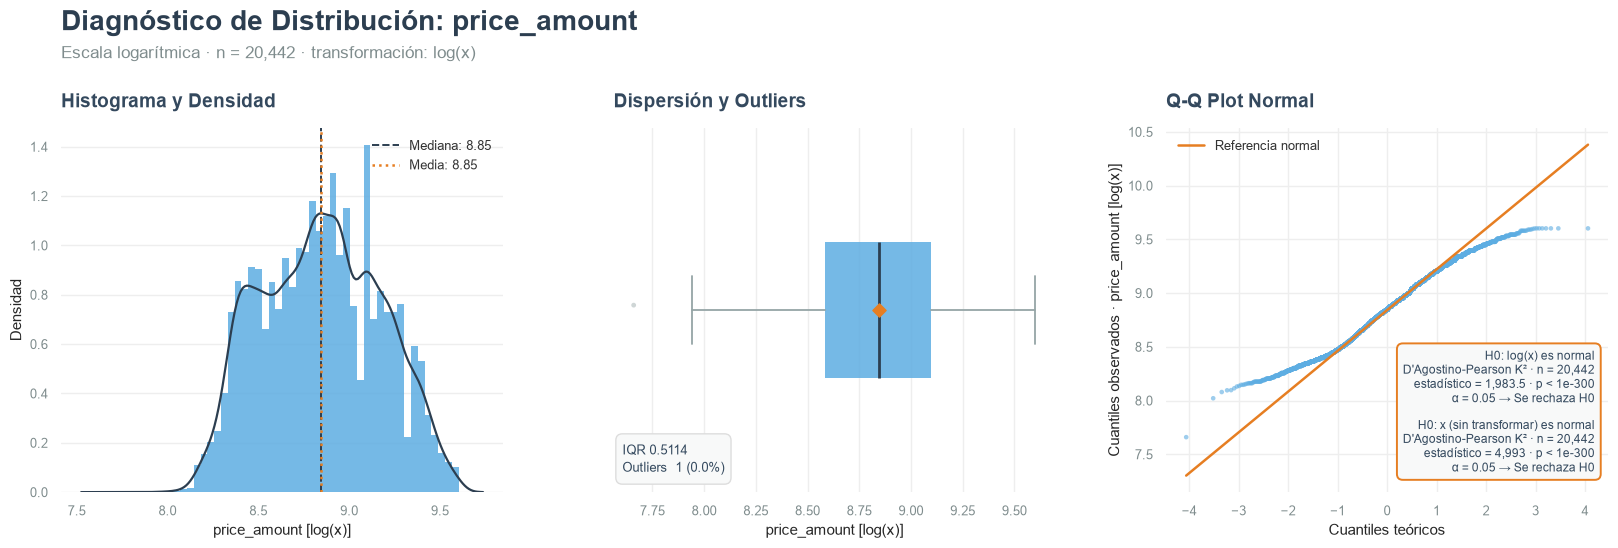

In [169]:
output = normality_report(
    df,
    'price_amount',
    log_transformation=True
    )

## Para `area_built_m2_log`

(a pesar de no ser normal se usará el modelo normal gamma al ser la herramienta dispotible que mejor modela esos datos)

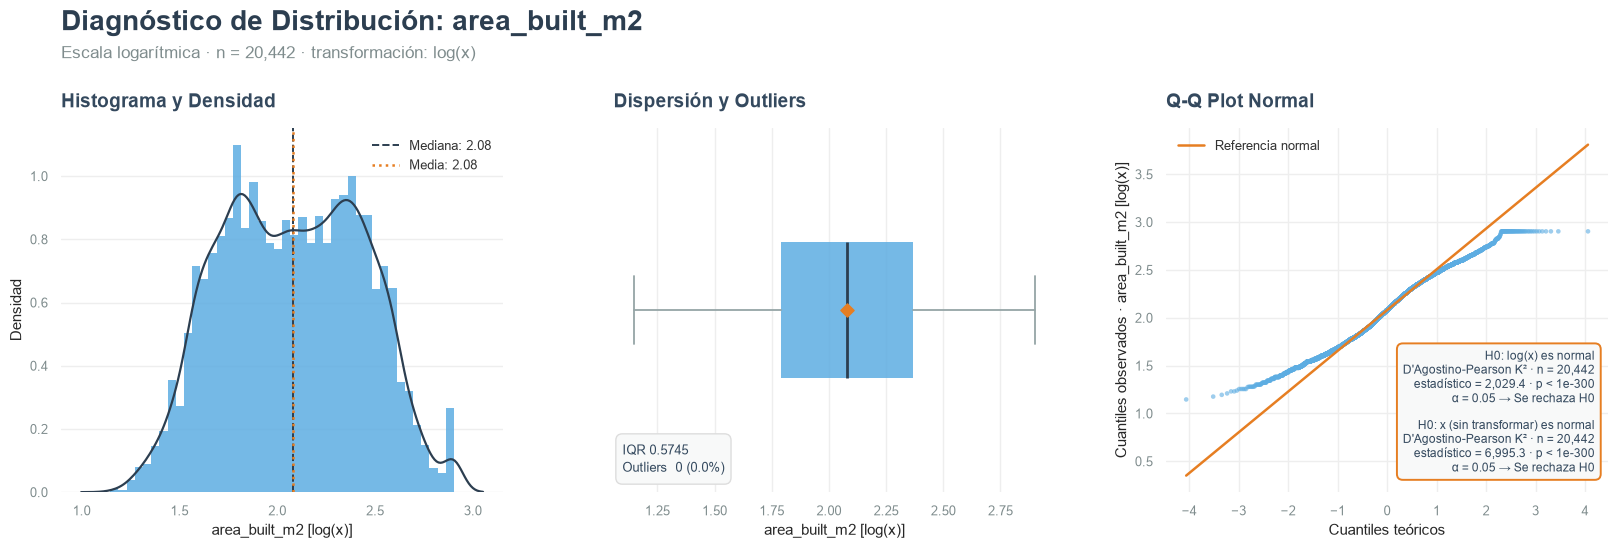

In [170]:
output = normality_report(
    df,
    'area_built_m2',
    log_transformation=True
    )